In [1]:
import numpy as np
from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from scipy.optimize import minimize
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

In [2]:
hamiltonian = SparsePauliOp.from_list(
    [("YZ", 0.3980), ("ZI", -0.3980), ("ZZ", -0.0113), ("XX", 0.1810)]
)

In [3]:
H = hamiltonian.to_matrix()
print(H)

[[-0.4093+0.j     0.    +0.j     0.    -0.398j  0.181 +0.j   ]
 [ 0.    +0.j    -0.3867+0.j     0.181 +0.j     0.    +0.398j]
 [ 0.    +0.398j  0.181 +0.j     0.4093+0.j     0.    +0.j   ]
 [ 0.181 +0.j     0.    -0.398j  0.    +0.j     0.3867+0.j   ]]


In [4]:
ansatz = efficient_su2(hamiltonian.num_qubits)

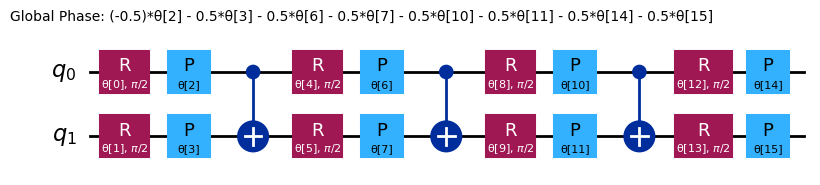

In [5]:
ansatz.decompose().draw("mpl")

In [6]:
num_params = ansatz.num_parameters
print(num_params)

16


In [7]:
print(hamiltonian.num_qubits)

2


In [8]:
def cost_func(params, ansatz, hamiltonian, estimator):
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    costs.append(energy)
    print(f"Iteration: {len(costs)+1}, cost: {energy}")

    return energy

In [9]:
costs = []

In [10]:
fake_backend = FakeManilaV2()

In [11]:
pm = generate_preset_pass_manager(backend=fake_backend, optimization_level=1)

ansatz_isa = pm.run(ansatz)
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

In [12]:
x0 = 2 * np.pi * np.random.random(num_params)
print(x0)

[1.60322237 1.14489681 4.3417645  2.80013571 2.57401974 0.19330681
 3.24435603 6.13774699 0.6802642  1.48472809 6.05423238 0.56814901
 5.99809535 4.40749723 3.54118167 5.73236118]


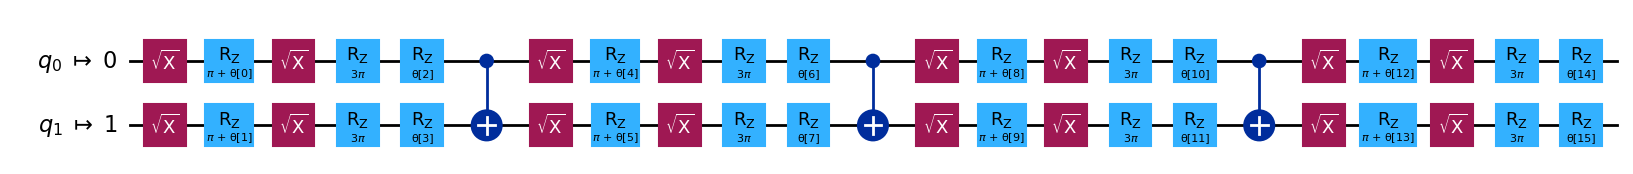

In [13]:
ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [14]:
with Session(backend=fake_backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 10000

    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
    )

Iteration: 2, cost: 0.19912702000000004
Iteration: 3, cost: 0.24626512000000003
Iteration: 4, cost: -0.08141907999999999
Iteration: 5, cost: -0.07768380000000003
Iteration: 6, cost: -0.004791839999999964
Iteration: 7, cost: 0.006839699999999976
Iteration: 8, cost: -0.09085036
Iteration: 9, cost: 0.0016790799999999856
Iteration: 10, cost: 0.07428388000000002
Iteration: 11, cost: -0.1157353
Iteration: 12, cost: -0.19720452
Iteration: 13, cost: -0.25716476
Iteration: 14, cost: -0.20982218
Iteration: 15, cost: -0.07604230000000001
Iteration: 16, cost: -0.19262436
Iteration: 17, cost: -0.22650250000000002
Iteration: 18, cost: -0.36921808
Iteration: 19, cost: -0.34845205999999995
Iteration: 20, cost: -0.41565122
Iteration: 21, cost: 0.0016534000000000132
Iteration: 22, cost: -0.43344858
Iteration: 23, cost: -0.26581045999999997
Iteration: 24, cost: -0.32690684000000003
Iteration: 25, cost: -0.39185686
Iteration: 26, cost: -0.4566225
Iteration: 27, cost: -0.40565282
Iteration: 28, cost: -0.41

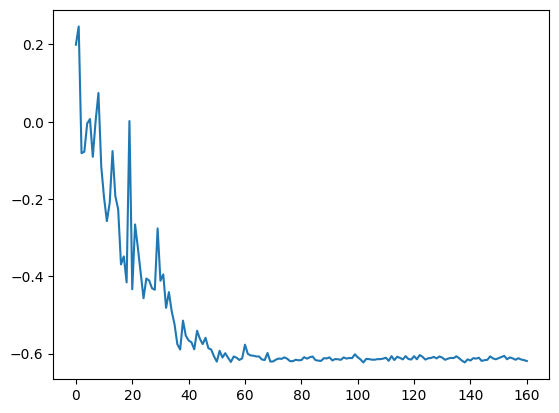

In [15]:
import matplotlib.pyplot as plt

plt.plot(costs)

## Exercise 1
Check using numpy what is the correct smallest eigenvalue of the hamiltonian.

## Exercise 2
Try to tune the VQE algorithm to lower the difference from correct value.

## Exercise 3
Implement VQE using ideal simulator and check if you are able to get proper lowest eigenvalue.